### **MACHINE LEARNING**

**Lab 7**

**Task 1: Dataset Exploration**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['Species'] = y

1. How many samples and features are present in the dataset?


In [4]:
print("\nNumber of Samples :", X.shape[0])
print("Number of Features:", X.shape[1])


Number of Samples : 150
Number of Features: 4


2. List the feature names and target classes.


In [5]:
print("\nFeature Names:")
print(iris.feature_names)

# Target classes
print("\nTarget Classes:")
print(iris.target_names)


Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']


3. Display the first five records.


In [8]:
print("\nFirst Five Records:")
print(df.head())


First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


4. Display the class distribution.


In [9]:
print("\nClass Distribution:")
print(df['Species'].value_counts())

print("\nSpecies Labels:")
for i, name in enumerate(iris.target_names):
    print(f"{i} --> {name}")


Class Distribution:
Species
0    50
1    50
2    50
Name: count, dtype: int64

Species Labels:
0 --> setosa
1 --> versicolor
2 --> virginica


**Task 2: Data Preparation**

1. Split the dataset into training (80%) and testing (20%) sets using random_state=42.


In [22]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 120
Testing Samples  : 30


2. Briefly explain why the dataset is divided into training and testing sets.


The dataset is divided into 80% training and 20% testing because this helps to check whether the model is making correct predictions and not just remembering the training data. It also gives a good balance between training and testing.



**Task 3: Building a Decision Tree Classifier**

1. Train a Decision Tree classifier using the default parameters.


In [14]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


2. Predict the class labels for the test dataset.


In [15]:
y_pred = dt.predict(X_test)

3. Evaluate the model using:<br>
Accuracy Score<br>
Confusion Matrix<br>
Classification Report


In [16]:
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy Score:")
print(acc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


Accuracy Score:
1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Task 4: Visualizing the Decision Tree**

1. Visualize the trained Decision Tree using plot_tree().


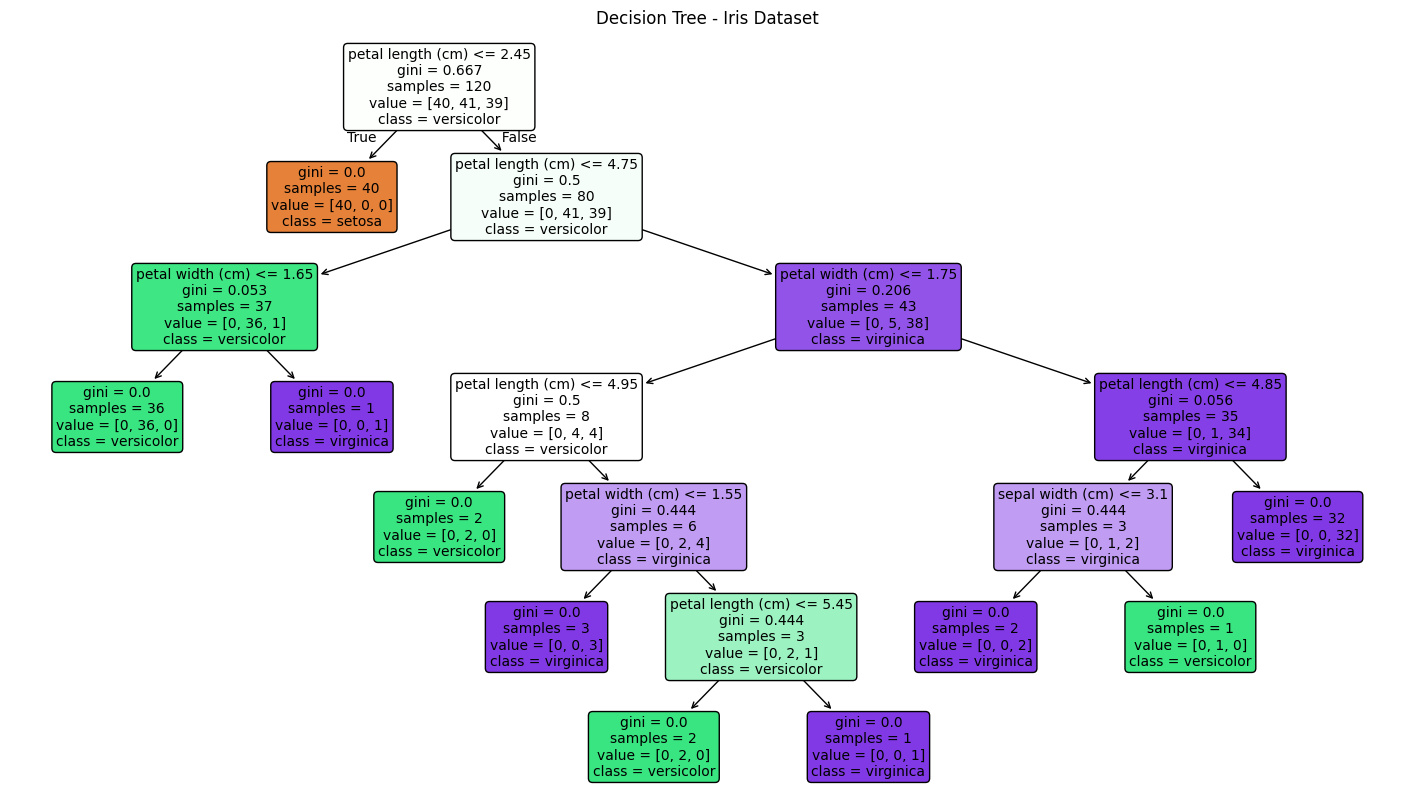

In [17]:
plt.figure(figsize=(18,10))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Iris Dataset")
plt.show()


Interpretation:

* The tree starts with petal length as the first split.
* It separates the flowers step by step using petal length & petal width.
* Setosa is identified very easily in the first split.
* Versicolor & virginica are separated using more splits.
* The tree has a maximum depth of 5.
* Most leaf nodes have gini = 0 which means the predictions are correct and the classes are well separated.


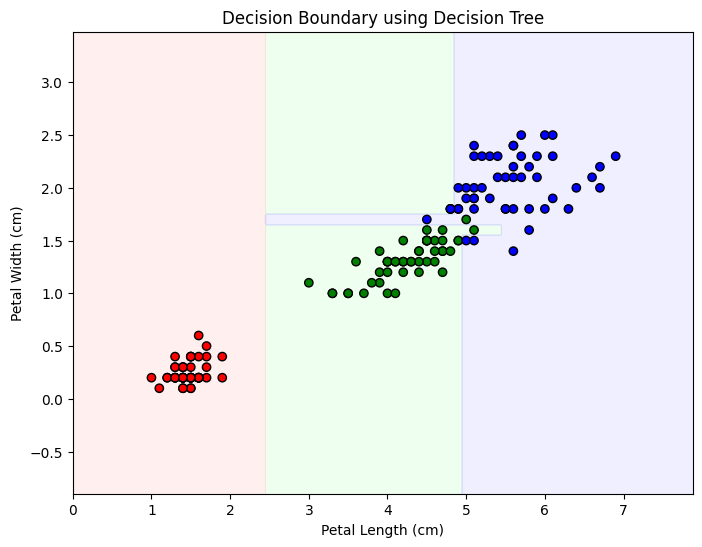

In [25]:

from matplotlib.colors import ListedColormap
iris = load_iris()

# Use Petal Length and Petal Width
X = iris.data[:, [2, 3]]
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Create mesh grid
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFCCCC','#CCFFCC','#CCCCFF']))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap=ListedColormap(['red','green','blue']),
    edgecolor='black'
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Boundary using Decision Tree")
plt.show()

Interpretation: The decision boundary clearly separates the three Iris flower classes using petal length and petal width resulting in accurate classification with very little overlap

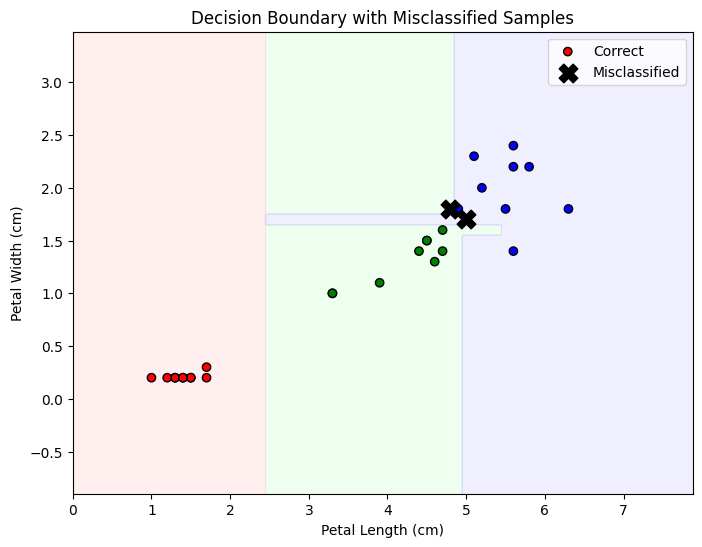

Accuracy: 0.9333333333333333
Misclassified Samples: 2


In [26]:
y_pred = model.predict(X_test)

misclassified = y_test != y_pred

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFCCCC','#CCFFCC','#CCCCFF']))

plt.scatter(
    X_test[~misclassified,0],
    X_test[~misclassified,1],
    c=y_test[~misclassified],
    cmap=ListedColormap(['red','green','blue']),
    edgecolor='black',
    label='Correct'
)

plt.scatter(
    X_test[misclassified,0],
    X_test[misclassified,1],
    marker='X',
    s=180,
    c='black',
    label='Misclassified'
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Boundary with Misclassified Samples")
plt.legend()
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Misclassified Samples:", np.sum(misclassified))

Interpretation: The graph shows that most test samples are classified correctly while only a few samples near the decision boundary are misclassified because the classes overlap in that region

2. From the visualization, identify:<br>
Root node<br>
Internal nodes<br>
Leaf nodes<br>
Maximum depth of the tree


Root node: Petal length (cm) ≤ 2.45 

Internal nodes:

  * Petal length (cm) ≤ 4.75
  * Petal width (cm) ≤ 1.65
  * Petal width (cm) ≤ 1.75
  * Petal length (cm) ≤ 4.95
  * Petal width (cm) ≤ 1.55
  * Petal length (cm) ≤ 5.45
  * Sepal width (cm) ≤ 3.1
  * Petal length (cm) ≤ 4.85

Leaf nodes: The last nodes with no further splits where the final class is predicted. In this tree, there are 9 leaf nodes.

Maximum depth of the tree: 5 (The longest path from the root node to a leaf node has 5 levels.)


3. Which feature is selected for the first split? Explain why you think this feature was chosen.

The first feature selected is Petal Length (cm). It was chosen because this feature gives the highest information gain also it separates the flower classes very well, especially Setosa from the other two classes.


**Task 5: Comparing Gini Index and Entropy**

In [18]:
results = []

criteria = ['gini', 'entropy']

for c in criteria:

    model = DecisionTreeClassifier(
        criterion=c,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    root = iris.feature_names[model.tree_.feature[0]]

    results.append([
        c,
        accuracy,
        depth,
        leaves,
        root
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Criterion",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes",
        "Root Feature"
    ]
)

print(comparison)

# Simpler tree
simple = comparison.sort_values(
    by=["Tree Depth","Leaf Nodes"]
).iloc[0]

print("\nSimpler Tree:")
print(simple)


  Criterion  Accuracy  Tree Depth  Leaf Nodes       Root Feature
0      gini       1.0           6          10  petal length (cm)
1   entropy       1.0           6          10  petal length (cm)

Simpler Tree:
Criterion                    gini
Accuracy                      1.0
Tree Depth                      6
Leaf Nodes                     10
Root Feature    petal length (cm)
Name: 0, dtype: object


Both Gini & Entropy give the same accuracy on the Iris dataset. Both models have the same tree depth (6) and same number of leaf nodes (10) so both trees are equally complex.


**Task 6: Effect of Maximum Tree Depth**

In [19]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depth_values = [1, 2, 3, 4, None]

results = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Observation
    if depth == 1:
        observation = "Underfitting"
    elif depth in [2, 3]:
        observation = "Good Generalization"
    elif depth == 4:
        observation = "Better Generalization"
    else:
        observation = "Possible Overfitting"

    results.append([
        depth,
        round(train_acc, 4),
        round(test_acc, 4),
        model.get_depth(),
        observation
    ])

# Display Table
depth_table = pd.DataFrame(results, columns=[
    "Max Depth",
    "Training Accuracy",
    "Testing Accuracy",
    "Tree Depth",
    "Observation"
])

print(depth_table)

   Max Depth  Training Accuracy  Testing Accuracy  Tree Depth  \
0        1.0             0.6750            0.6333           1   
1        2.0             0.9500            0.9667           2   
2        3.0             0.9583            1.0000           3   
3        4.0             0.9750            1.0000           4   
4        NaN             1.0000            1.0000           6   

             Observation  
0           Underfitting  
1    Good Generalization  
2    Good Generalization  
3  Better Generalization  
4   Possible Overfitting  


1. Which model is underfitting?


The model with max_depth = 1 is underfitting because it has low training accuracy & low testing accuracy which means the tree is too simple to learn the patterns in the dataset.

2. Which model gives the best generalization?

The model with max_depth = 3 gives the best generalization because it achieves 100% testing accuracy with a smaller tree depth (3) so it performs well on unseen data without making the tree too complex.

3. Which model is likely to overfit? Justify your answer.

The model with max_depth = None is likely to overfit because it has 100% training accuracy and grows to the maximum tree depth (6). Although it also gives 100% testing accuracy on the Iris dataset a fully grown tree may not generalize well to new datasets and therefore t is more likely to overfit.


**Task 7: Effect of min_samples_split**

In [21]:

leaf_values = [1,2,5,10]

leaf_results = []

for l in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=l,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,pred)

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    if l==1:
        obs="Most Detailed Tree"
    elif l<=5:
        obs="Balanced Tree"
    else:
        obs="Simpler Tree"

    leaf_results.append([
        l,
        round(accuracy,4),
        depth,
        leaves,
        obs
    ])

leaf_df = pd.DataFrame(
    leaf_results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes",
        "Observation"
    ]
)

print(leaf_df)

   min_samples_leaf  Accuracy  Tree Depth  Leaf Nodes         Observation
0                 1    1.0000           6          10  Most Detailed Tree
1                 2    1.0000           5           8       Balanced Tree
2                 5    1.0000           4           6       Balanced Tree
3                10    0.9667           4           6        Simpler Tree


Qn: State how increasing min_samples_split affects the complexity of the Decision Tree.

As min_samples_split increases the Decision Tree becomes simpler because fewer splits are allowed. This reduces the tree depth and number of leaf nodes helping to reduce overfitting but very large values may lower the model's accuracy

**Task 8: Effect of min_samples_leaf**

In [23]:
leaf_values = [1,2,5,10]

leaf_results = []

for l in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=l,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,pred)

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    if l==1:
        obs="Most Detailed Tree"
    elif l<=5:
        obs="Balanced Tree"
    else:
        obs="Simpler Tree"

    leaf_results.append([
        l,
        round(accuracy,4),
        depth,
        leaves,
        obs
    ])

leaf_df = pd.DataFrame(
    leaf_results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes",
        "Observation"
    ]
)

print(leaf_df)

   min_samples_leaf  Accuracy  Tree Depth  Leaf Nodes         Observation
0                 1    1.0000           6          10  Most Detailed Tree
1                 2    1.0000           5           8       Balanced Tree
2                 5    1.0000           4           6       Balanced Tree
3                10    0.9667           4           6        Simpler Tree


Qn: Explain how changing min_samples_leaf influences overfitting.

As the value of min_samples_leaf increases the Decision Tree becomes simpler which helps to reduce overfitting because the tree does not create very small leaf nodes. But when min_samples_leaf = 10 the accuracy decreases from 100% to 96.67%, showing that a very high value can make the model too simple and may lead to underfitting.

**Task 9 Answer the following questions.**


1. What is the role of the criterion parameter in a Decision Tree?<br>
The criterion decides how the best feature is selected for splitting the data. Common criteria are Gini and Entropy.

2. How does max_depth influence underfitting and overfitting?<br>
A small max_depth can cause underfitting, while a large max_depth can cause overfitting by making the tree too complex.

3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?<br>
Larger values reduce the number of splits, so the tree has fewer nodes and becomes simpler, helping to reduce overfitting.

4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.<br>
max_depth had the greatest impact because increasing it improved the accuracy from 63.33% to 100%, while also increasing the tree complexity.

5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.<br>
The model with max_depth = 3 is the most suitable because it achieved 100% testing accuracy with a simpler tree, giving good generalization.